In [148]:
!pip install langchain langchain_openai langgraph langchain_core langsmith langchain_experimental


In [149]:
!pip install pandas matplotlib

In [150]:
import json
from langchain_core.messages import  (
    AIMessage,
    BaseMessage,
    ChatMessage,
    FunctionMessage,
    HumanMessage
)
from langchain.tools.render import format_tool_to_openai_function
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph
from langgraph.prebuilt.tool_executor import ToolExecutor, ToolInvocation

In [151]:
import os
os.environ['TAVILY_API_KEY'] = ""

In [152]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults(max_results=5)

In [153]:
from langchain_experimental.utilities import PythonREPL
from typing import Annotated

repl = PythonREPL()
@tool
def python_repl(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code. If you want to see the output of a value, you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    return f"Succesfully executed:\\\\n`python\\\\\\\\n{code}\\\\\\\\n`\\\\nStdout: {result}"


In [154]:
tools = [tavily_tool, python_repl]

In [155]:
import re

def sanitize_name(name: str) -> str:
    """Sanitize and validate the name to match the pattern ^[a-zA-Z0-9_-]+$."""
    if not re.match(r"^[a-zA-Z0-9_-]+$", name):
        # Replace invalid characters with underscores
        sanitized_name = re.sub(r"[^a-zA-Z0-9_-]", "_", name)
        if sanitized_name == "":
            raise ValueError("Invalid name: cannot be empty after sanitization.")
        return sanitized_name
    return name


In [156]:
import operator
from typing import Annotated, List, Sequence, Tuple, TypedDict, Union
from langchain.agents import create_openai_functions_agent
from langchain.tools.render import format_tool_to_openai_function
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: str


In [157]:
tool_executor = ToolExecutor(tools)

def tool_node(state):
    """This runs tools in the graph
    It takes in an agent action and calls that tool and returns the result."""
    messages = state["messages"]
    # Based on the continue condition
    # we know the last message involves a function call
    last_message = messages[-1]
    # We construct an ToolInvocation from the function_call
    tool_input = json.loads(
        last_message.additional_kwargs["function_call"]["arguments"]
    )
    # We can pass single-arg inputs by value
    if len(tool_input) == 1 and "__arg1" in tool_input:
        tool_input = next(iter(tool_input.values()))
    tool_name = last_message.additional_kwargs["function_call"]["name"]
    action = ToolInvocation(
        tool=tool_name,
        tool_input=tool_input,
    )
    # We call the tool_executor and get back a response
    response = tool_executor.invoke(action)
    # We use the response to create a FunctionMessage
    function_message = FunctionMessage(
        content=f"{tool_name} response: {str(response)}", name=action.tool
    )
    # We return a list, because this will get added to the existing list
    return {"messages": [function_message]}


<ipython-input-157-7f1dbedf2b17>:1: LangGraphDeprecationWarning: ToolExecutor is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  tool_executor = ToolExecutor(tools)


In [158]:
def router(state):
    # This is the router
    messages = state["messages"]
    last_message = messages[-1]
    if "function_call" in last_message.additional_kwargs:
        # The previous agent is invoking a tool
        return "call_tool"
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return "end"
    return "continue"


In [159]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(api_key="",
                 model="gpt-4")


In [160]:
import json
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    ChatMessage,
    FunctionMessage,
    HumanMessage,
)
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph
from langgraph.prebuilt.tool_executor import ToolExecutor, ToolInvocation

In [161]:
def create_agent(llm, tools, system_message: str):
    """Create an agent."""
    functions = [convert_to_openai_function(t) for t in tools]
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant, collaborating with other assistants."
                " Use the provided tools to progress towards answering the question."
                " If you are unable to fully answer, that's OK, another assistant with different tools "
                " will help where you left off. Execute what you can to make progress."
                " If you or any of the other assistants have the final answer or deliverable,"
                " prefix your response with FINAL ANSWER so the team knows to stop."
                " You have access to the following tools: {tool_names}.\\\\n{system_message}",
            ),
            MessagesPlaceholder(variable_name="messages"),
        ]
    )
    prompt = prompt.partial(system_message=system_message)
    prompt = prompt.partial(tool_names=", ".join([tool.name for tool in tools]))
    return prompt | llm.bind_functions(functions)


In [162]:
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # We convert the agent output into a format that is suitable to append to the global state
    if isinstance(result, FunctionMessage):
        pass
    else:
        result = HumanMessage(**result.model_dump(exclude={"type", "name"}), name=name)
    return {
        "messages": [result],
        # Since we have a strict workflow, we can
        # track the sender so we know who to pass to next.
        "sender": name,
    }


In [163]:
research_agent = create_agent(
    llm,
    [tavily_tool],
    system_message="You should provide accurate data for the chart generator to use.",
)

In [164]:
chart_agent= create_agent(
    llm,
    [python_repl],
    system_message="Any charts you display will be visible by the user.",
)

In [165]:
def sanitize_messages(messages):
    """Sanitize all names in the message list."""
    for message in messages:
        if hasattr(message, "name"):
            message.name = sanitize_name(message.name)
    return messages

# Apply this to the initial state
initial_state = {
    "messages": sanitize_messages([
        HumanMessage(content="Fetch Pakistan's GDP over the past 5 years", name="Human"),
    ]),
}

In [166]:
import functools

research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")
chart_node = functools.partial(agent_node, agent=chart_agent, name="Chart Generator")

workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Chart Generator", chart_node)
workflow.add_node("call_tool", tool_node)

workflow.add_conditional_edges(
    "Researcher",
    router,
    {"continue": "Chart Generator", "call_tool": "call_tool", "end": END},
)

workflow.add_conditional_edges(
    "Chart Generator",
    router,
    {"continue": "Researcher", "call_tool": "call_tool", "end": END},
)

workflow.add_conditional_edges(
    "call_tool",
    lambda x: x["sender"],
    {
        "Researcher": "Researcher",
        "Chart Generator": "Chart Generator",
    },
)

workflow.set_entry_point("Researcher")
graph = workflow.compile()


{'Researcher': {'messages': [HumanMessage(content='', additional_kwargs={'function_call': {'arguments': '{\n  "query": "history of Land Cruiser pricing in USA"\n}', 'name': 'tavily_search_results_json'}, 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 243, 'total_tokens': 269, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'finish_reason': 'function_call', 'logprobs': None}, name='Researcher', id='run-d4eed03a-94bb-49b5-8bdb-ed791c3de703-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 243, 'output_tokens': 26, 'total_tokens': 269, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})], 'sender': 'Researcher'}}
----


<ipython-input-157-7f1dbedf2b17>:18: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


{'call_tool': {'messages': [FunctionMessage(content='tavily_search_results_json response: [{\'url\': \'https://autotrends.org/toyota-land-cruiser-history/\', \'content\': "The Toyota Land Cruiser serves as a trail-hearty SUV, capable of dominating the path less traveled. Though the Land Cruiser originally came from humble utilitarian-esque beginnings, Toyota\'s premier trail-runner eventually came to embody a more ... Final Model Year: 2021 (US) Original Price in 1958: $3,000 (around $32k USD today) Total Sold: 10"}, {\'url\': \'https://www.caranddriver.com/features/g20901778/cruisin-for-a-bruisin-the-visual-history-of-the-toyota-land-cruiser/\', \'content\': \'Decades later, the FJ Company loans us a thoroughly restored and modernized 1981 FJ43 Land Cruiser that includes top-notch build quality and sports a $200,000 price of entry. Advertisement\'}, {\'url\': \'https://www.classic.com/m/toyota/land-cruiser/\', \'content\': \'A: The top sale price was $270,000 for a 1970 Toyota Land Cr

<ipython-input-157-7f1dbedf2b17>:18: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


{'call_tool': {'messages': [FunctionMessage(content='tavily_search_results_json response: [{\'url\': \'https://www.clublexus.com/articles/2024-toyota-land-cruiser-preview/\', \'content\': \'2024 Toyota Land Cruiser debuts honoring the past with three grades — 1958, Land Cruiser, & First Edition — and a mid-$50K starting MSRP. When the Land Cruiser 200 Series ended production after the 2020 model year, it was the sister model to the three-row Lexus LX with a mid-$80,000 base MSRP. It was big and luxurious and capable, but a far cry from the original models.\'}, {\'url\': \'https://www.truecar.com/new-cars-for-sale/listings/toyota/land-cruiser/year-2024/?trim=1958\', \'content\': \'Search over 274 new 2024 Toyota Land Cruiser 1958. TrueCar has over 1,041,929 listings nationwide, updated daily. Come find a great deal on new 2024 Toyota Land Cruiser 1958 in your area today! ... The original MSRP for the 2024 Toyota Land Cruiser started at $57,400 for the 1958 and went up to $76,400 for the

...

<ipython-input-157-7f1dbedf2b17>:18: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


{'call_tool': {'messages': [FunctionMessage(content='tavily_search_results_json response: [{\'url\': \'https://www.carfax.com/Used-2010-Toyota-Land-Cruiser_z7558\', \'content\': \'We have 8 2010 Toyota Land Cruiser vehicles for sale that are reported accident free, 4 1-Owner cars, and 19 personal use cars. ... The original MSRP of the 2010 Toyota Land Cruiser is from $65,970. The data above is updated daily, based on used car inventory for sale on CARFAX for the last five model years of this car.\'}, {\'url\': \'https://toyota-specs.com/cars/2010/cruiser4.0/specs.php\', \'content\': \'2008 - 2021 Land Cruiser 4.0L. Specs. Torque Specs. 2010 Toyota cruiser Specifications General. Basics; Vehicle Type: 4dr SUV: BASE MSRP(US) $64,100.00: Warranty: 3 yr./ 36000 mi. Power / Horsepower: 239 HP @ 5200 rpm: Torque : 278 ft-lb @ 3700 rpm: MPG (Economy) 16 city / 20 highway\'}, {\'url\': \'https://www.thecarconnection.com/specifications/toyota_land-cruiser_2010\', \'content\': \'MSRP. 4-Door 4WD

<ipython-input-157-7f1dbedf2b17>:18: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


{'call_tool': {'messages': [FunctionMessage(content="tavily_search_results_json response: [{'url': 'https://www.carfax.com/Research-2020-Toyota-Land-Cruiser_z37532', 'content': '2020 Toyota Land Cruiser Pricing. The data below is updated daily, based on used car inventory for sale on CARFAX. Original MSRP: $85,415 - $87,745: Avg. Price on CARFAX: $72,796: Avg. CARFAX Value: $71,190: 2020 Toyota Land Cruiser Pricing By Trim. Heritage Edition. CARFAX Price Range. $79,998 - $86,541. Avg. Price on CARFAX.'}, {'url': 'https://www.kbb.com/toyota/land-cruiser/2020/specs/', 'content': 'The 2020 Toyota Land Cruiser comes in 2 different trims, ranging from the Heritage Edition Sport Utility 4D with a base MSRP of $67,696.00 to the Sport Utility 4D with a base MSRP of $69,455.00.'}, {'url': 'https://cars.usnews.com/cars-trucks/toyota/land-cruiser/2020/specs', 'content': '2020 Toyota Land Cruiser Configurations. Select up to 3 trims below to compare some key specs and options for the 2020 Toyota L

<ipython-input-157-7f1dbedf2b17>:18: LangGraphDeprecationWarning: ToolInvocation is deprecated as of version 0.2.0 and will be removed in 0.3.0. Use langgraph.prebuilt.ToolNode instead.
  action = ToolInvocation(


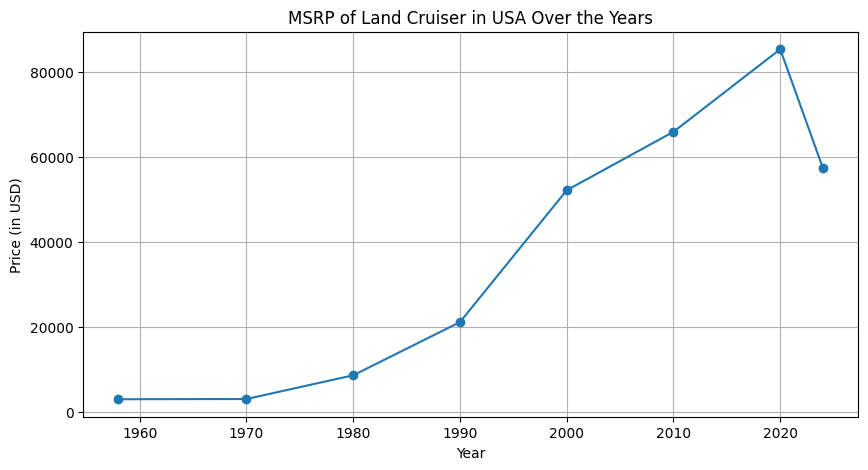

{'call_tool': {'messages': [FunctionMessage(content="python_repl response: Succesfully executed:\\\\n`python\\\\\\\\nimport matplotlib.pyplot as plt\n\nyears = [1958, 1970, 1980, 1990, 2000, 2010, 2020, 2024]\nprices = [3000, 3048, 8638, 21163, 52208, 65970, 85415, 57400]\n\nplt.figure(figsize=(10, 5))\nplt.plot(years, prices, marker='o')\nplt.title('MSRP of Land Cruiser in USA Over the Years')\nplt.xlabel('Year')\nplt.ylabel('Price (in USD)')\nplt.grid(True)\nplt.show()\\\\\\\\n`\\\\nStdout: ", additional_kwargs={}, response_metadata={}, name='python_repl')]}}
----


BadRequestError: Error code: 400 - {'error': {'message': "Invalid 'messages[21].name': string does not match pattern. Expected a string that matches the pattern '^[a-zA-Z0-9_-]+$'.", 'type': 'invalid_request_error', 'param': 'messages[21].name', 'code': 'invalid_value'}}

In [177]:
for s in graph.stream(
    {
        "messages": [
            HumanMessage(
                content="Fetch the MSRP of a Land Cruiser in USA since the year it was introduced until 2024 (skip any year that you cannot find reliable data for)"
                " then draw a line graph of it."
                " Once you code it up, finish."
            )
        ],
    },
    {"recursion_limit": 150},
):
    print(s)
    print("----")
